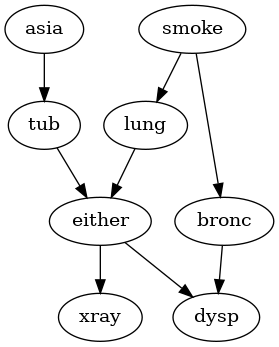

In [3]:
# Fetch the asia model from the bnlearn repository

from pgmpy.utils import get_example_model
from IPython.display import Image

asia_model = get_example_model("asia")

asia_junction_tree = asia_model.to_junction_tree()

# Visualize the model
viz = asia_model.to_graphviz()
viz.draw('asia.png', prog='dot')
Image('asia.png')

- **A** (*Visit to Asia*): Has the patient recently visited Asia?
- **S** (*Smoking*): Does the patient smoke?
- **T** (*Tuberculosis*): Does the patient have tuberculosis?
- **L** (*Lung Cancer*): Does the patient have lung cancer?
- **B** (*Bronchitis*): Does the patient have bronchitis?
- **E** (*Either*): Does the patient have **tuberculosis or lung cancer**?
- **X** (*Chest X-ray*): Is the patient’s chest X-ray abnormal?
- **D** (*Dyspnoea*): Is the patient experiencing shortness of breath?

In [4]:
print("Nodes: ", asia_model.nodes())
print("Edges: ", asia_model.edges())

Nodes:  ['asia', 'tub', 'smoke', 'lung', 'bronc', 'either', 'xray', 'dysp']
Edges:  [('asia', 'tub'), ('tub', 'either'), ('smoke', 'lung'), ('smoke', 'bronc'), ('lung', 'either'), ('bronc', 'dysp'), ('either', 'xray'), ('either', 'dysp')]


In [5]:
asia_cpd = asia_model.get_cpds("asia")
print(asia_cpd)

smoke_cpd = asia_model.get_cpds("smoke")
print(smoke_cpd)

+-----------+------+
| asia(yes) | 0.01 |
+-----------+------+
| asia(no)  | 0.99 |
+-----------+------+
+------------+-----+
| smoke(yes) | 0.5 |
+------------+-----+
| smoke(no)  | 0.5 |
+------------+-----+


In [6]:
tub_cpd = asia_model.get_cpds("tub")
print(tub_cpd)

+----------+-----------+----------+
| asia     | asia(yes) | asia(no) |
+----------+-----------+----------+
| tub(yes) | 0.05      | 0.01     |
+----------+-----------+----------+
| tub(no)  | 0.95      | 0.99     |
+----------+-----------+----------+


In [7]:
lung_cpd = asia_model.get_cpds("lung")
print(lung_cpd)

+-----------+------------+-----------+
| smoke     | smoke(yes) | smoke(no) |
+-----------+------------+-----------+
| lung(yes) | 0.1        | 0.01      |
+-----------+------------+-----------+
| lung(no)  | 0.9        | 0.99      |
+-----------+------------+-----------+


In [8]:
bronc_cpd = asia_model.get_cpds("bronc")
print(bronc_cpd)

+------------+------------+-----------+
| smoke      | smoke(yes) | smoke(no) |
+------------+------------+-----------+
| bronc(yes) | 0.6        | 0.3       |
+------------+------------+-----------+
| bronc(no)  | 0.4        | 0.7       |
+------------+------------+-----------+


In [9]:
either_cpd = asia_model.get_cpds("either")
print(either_cpd)

+-------------+-----------+-----------+----------+----------+
| lung        | lung(yes) | lung(yes) | lung(no) | lung(no) |
+-------------+-----------+-----------+----------+----------+
| tub         | tub(yes)  | tub(no)   | tub(yes) | tub(no)  |
+-------------+-----------+-----------+----------+----------+
| either(yes) | 1.0       | 1.0       | 1.0      | 0.0      |
+-------------+-----------+-----------+----------+----------+
| either(no)  | 0.0       | 0.0       | 0.0      | 1.0      |
+-------------+-----------+-----------+----------+----------+


In [10]:
xray_cpd = asia_model.get_cpds("xray")
print(xray_cpd)

+-----------+-------------+------------+
| either    | either(yes) | either(no) |
+-----------+-------------+------------+
| xray(yes) | 0.98        | 0.05       |
+-----------+-------------+------------+
| xray(no)  | 0.02        | 0.95       |
+-----------+-------------+------------+


In [11]:
dysp_cpd = asia_model.get_cpds("dysp")
print(dysp_cpd)

+-----------+-------------+------------+-------------+------------+
| bronc     | bronc(yes)  | bronc(yes) | bronc(no)   | bronc(no)  |
+-----------+-------------+------------+-------------+------------+
| either    | either(yes) | either(no) | either(yes) | either(no) |
+-----------+-------------+------------+-------------+------------+
| dysp(yes) | 0.9         | 0.8        | 0.7         | 0.1        |
+-----------+-------------+------------+-------------+------------+
| dysp(no)  | 0.1         | 0.2        | 0.3         | 0.9        |
+-----------+-------------+------------+-------------+------------+


In [ ]:
# Initializing the VariableElimination class

from pgmpy.inference import VariableElimination

asia_ve_infer = VariableElimination(asia_model)

In [24]:
# Computing the probability of bronc given smoke=no.
q = asia_ve_infer.query(variables=["bronc"], evidence={"smoke": "no"})
print(q)


# Evidence should not be eliminated but induced_width expect a complete elimination order
elimination_order_1 = ["dysp", "asia", "tub", "lung", "either", "xray", "smoke", "bronc"]
elimination_order_2 = ["either", "dysp", "tub", "asia", "lung", "xray", "smoke", "bronc"]
w = asia_ve_infer.induced_width(elimination_order_2)
print(f"induced width: {w}")

asia_induced_graph = asia_ve_infer.induced_graph(elimination_order_2)
fill_edge = asia_induced_graph.has_edge("tub", "lung")
fill_edge

+------------+--------------+
| bronc      |   phi(bronc) |
+============+==============+
| bronc(yes) |       0.3000 |
+------------+--------------+
| bronc(no)  |       0.7000 |
+------------+--------------+
induced width: 5


True

In [14]:
asia_junction_tree.clique_beliefs

{('either',
  'smoke',
  'bronc',
  'dysp'): <DiscreteFactor representing phi(bronc:2, smoke:2, either:2, dysp:2) at 0x7b388a333b60>,
 ('either',
  'smoke',
  'xray',
  'asia',
  'lung'): <DiscreteFactor representing phi(xray:2, smoke:2, asia:2, either:2, lung:2) at 0x7b388a333980>,
 ('either',
  'tub',
  'asia',
  'lung'): <DiscreteFactor representing phi(asia:2, tub:2, either:2, lung:2) at 0x7b388a3339e0>}